# 08 — Passing Dominance & Defensive Resistance
## When does passing dominance fail to produce wins?

**Main research question:**
When does passing dominance fail to produce wins, and can defensive-player resistance help explain why lower-possession teams still win?

**Why this matters:**
In football, the team with more passes doesn't always win. Spain dominated possession vs Saudi Arabia. Argentina dominated vs Saudi Arabia and lost. Germany dominated vs Japan and lost. This notebook explores *when* and *why* passing dominance fails — and whether the winning team's defenders played a key role in absorbing pressure and launching counterattacks.

**What this notebook covers:**
1. Team-level passing metrics per match
2. Passing dominance score (which team controlled the ball more meaningfully)
3. How often the dominant team wins
4. "Failed dominance" matches — where the passing-dominant team lost
5. Defensive player analysis for the lower-passing winners
6. Summary and interpretation

> **Note:** This is exploratory analysis on a small dataset (128 matches across 2018 and 2022). We are not building a prediction model — we are asking whether passing patterns *explain* match outcomes after the fact.

In [1]:
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy.stats import pointbiserialr
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')

# ── Folder paths ──────────────────────────────────────────────────────────
DATA_DIR   = Path('../data/processed')
EVENTS_22  = Path('../data/raw/events')          # 2022 cached parquets
EVENTS_18  = Path('../data/raw/2018/events')     # 2018 cached parquets
FIG_DIR    = Path('../outputs/figures')
TABLE_DIR  = Path('../outputs/tables')
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# ── Load both tournament match-level files ────────────────────────────────
df_2022 = pd.read_csv(DATA_DIR / 'team_match_network_features_normalized.csv')
df_2022['tournament_year'] = 2022

df_2018 = pd.read_csv(DATA_DIR / '2018_match_features.csv')

# Combine into one table — one row per (team, match)
team_matches = pd.concat([df_2022, df_2018], ignore_index=True)

print(f"Loaded {len(team_matches)} team-match rows")
print(f"  2022: {(team_matches['tournament_year'] == 2022).sum()} rows")
print(f"  2018: {(team_matches['tournament_year'] == 2018).sum()} rows")
print(f"\nColumns available:")
for col in team_matches.columns:
    non_null = team_matches[col].notna().sum()
    print(f"  {col:<45} non-null: {non_null}")

Loaded 256 team-match rows
  2022: 128 rows
  2018: 128 rows

Columns available:
  tournament_year                               non-null: 256
  match_id                                      non-null: 256
  match_name                                    non-null: 256
  date                                          non-null: 256
  stage                                         non-null: 256
  team                                          non-null: 256
  opponent                                      non-null: 256
  goals_for                                     non-null: 256
  goals_against                                 non-null: 256
  match_result                                  non-null: 256
  completed_passes                              non-null: 256
  unique_passing_pairs                          non-null: 256
  num_players                                   non-null: 256
  network_density                               non-null: 256
  top_player_reliance                           non

## Section 1 — Reshape to One Row Per Match

Right now each row is one team in one match. To compare teams against each other, we need to reshape so each row represents one full match with both teams' stats side by side.

For each match we create **difference features** — e.g. `completed_passes_diff` tells us how many more passes Team A completed compared to Team B.

In [2]:
# These are the passing metrics we want to compare between teams.
# We only keep a metric if it actually exists in the data.
PASSING_METRICS = [
    'completed_passes',
    'network_density',
    'progressive_passes',
    'final_third_entries',
    'final_third_entries_per_100_passes',
    'key_passes',
    'through_balls',
    'crosses',
    'passes_per_connection',
    'connections_per_100_passes',
    'unique_passing_pairs',
    'top_player_reliance',
]

# Only keep metrics that exist in our dataset
PASSING_METRICS = [m for m in PASSING_METRICS if m in team_matches.columns]
print(f"Metrics available for analysis: {PASSING_METRICS}")

# ── Build one row per match ───────────────────────────────────────────────
match_rows = []

for (year, match_id), group in team_matches.groupby(['tournament_year', 'match_id']):
    if len(group) != 2:
        continue   # skip if we don't have both teams

    # Sort by completed passes — team_a has more passes (the "dominant" team)
    group = group.sort_values('completed_passes', ascending=False).reset_index(drop=True)
    team_a = group.iloc[0]   # more passes
    team_b = group.iloc[1]   # fewer passes

    # Build the match row
    row = {
        'tournament_year':    year,
        'match_id':           match_id,
        'match_name':         team_a['match_name'],
        'stage':              team_a['stage'],
        'date':               team_a.get('date', ''),
        'team_a':             team_a['team'],            # more passes
        'team_b':             team_b['team'],            # fewer passes
        'team_a_result':      team_a['match_result'],    # W / D / L
        'goals_a':            team_a['goals_for'],
        'goals_b':            team_a['goals_against'],
    }

    # Add each metric for both teams, plus the difference (a minus b)
    for metric in PASSING_METRICS:
        row[f'a_{metric}'] = team_a[metric]
        row[f'b_{metric}'] = team_b[metric]
        row[f'{metric}_diff'] = team_a[metric] - team_b[metric]

    match_rows.append(row)

matches = pd.DataFrame(match_rows)

print(f"\nMatch-level table: {len(matches)} matches × {len(matches.columns)} columns")
print(f"\nFirst 3 matches:")
print(matches[['match_name', 'stage', 'team_a', 'team_b', 'team_a_result',
               'completed_passes_diff', 'goals_a', 'goals_b']].head(3).to_string(index=False))

Metrics available for analysis: ['completed_passes', 'network_density', 'progressive_passes', 'final_third_entries', 'final_third_entries_per_100_passes', 'key_passes', 'through_balls', 'crosses', 'passes_per_connection', 'connections_per_100_passes', 'unique_passing_pairs', 'top_player_reliance']

Match-level table: 128 matches × 46 columns

First 3 matches:
            match_name stage       team_a    team_b team_a_result  completed_passes_diff  goals_a  goals_b
Russia vs Saudi Arabia group Saudi Arabia    Russia             L                    186        0        5
    Croatia vs Nigeria group      Croatia   Nigeria             W                     70        2        0
   France vs Australia group       France Australia             W                    103        2        1


## Section 2 — Passing Dominance Score

Instead of using just one metric (like completed passes), we create a **Passing Dominance Score** that combines several metrics into one number.

**How it works:**
1. For each metric, we scale Team A's value relative to Team B using min-max scaling across all matches
2. We average the scaled values to get one score between 0 and 1
3. A score above 0.5 means Team A was more dominant; below 0.5 means Team B was

**Metrics included** (volume + structure + attacking):

In [3]:
# Metrics to include in the dominance score
# We use the "diff" columns (team_a minus team_b) so a positive value = team_a is higher
DOMINANCE_METRICS = [m for m in [
    'completed_passes',
    'network_density',
    'progressive_passes',
    'final_third_entries',
    'key_passes',
] if f'{m}_diff' in matches.columns]

print(f"Dominance score built from: {DOMINANCE_METRICS}")

# Scale each diff column to 0–1 range across all matches
scaler = MinMaxScaler()
diff_cols = [f'{m}_diff' for m in DOMINANCE_METRICS]
scaled = scaler.fit_transform(matches[diff_cols].fillna(0))

# Average the scaled values → one dominance score per match
matches['dominance_score'] = scaled.mean(axis=1).round(3)

# A score above 0.5 means team_a was more dominant overall
matches['team_a_dominant'] = matches['dominance_score'] > 0.5

# Did the passing-dominant team win?
matches['dominant_team_won']  = matches['team_a_result'] == 'W'
matches['dominant_team_drew'] = matches['team_a_result'] == 'D'
matches['dominant_team_lost'] = matches['team_a_result'] == 'L'

# Goal difference from team_a perspective
matches['goal_diff_a'] = matches['goals_a'] - matches['goals_b']

print(f"\nDominance score range: {matches['dominance_score'].min():.3f} – {matches['dominance_score'].max():.3f}")
print(f"Mean score: {matches['dominance_score'].mean():.3f}  (0.5 = perfectly balanced)")
print(f"\nSample — most extreme dominance matches:")
top = matches.nlargest(5, 'dominance_score')[['match_name', 'tournament_year', 'stage', 'dominance_score', 'team_a_result', 'goals_a', 'goals_b']]
print(top.to_string(index=False))

Dominance score built from: ['completed_passes', 'network_density', 'progressive_passes', 'final_third_entries', 'key_passes']

Dominance score range: 0.121 – 0.936
Mean score: 0.382  (0.5 = perfectly balanced)

Sample — most extreme dominance matches:
          match_name  tournament_year stage  dominance_score team_a_result  goals_a  goals_b
     Spain vs Russia             2018   R16            0.936             D        1        1
 Spain vs Costa Rica             2022 group            0.800             W        7        0
Argentina vs Iceland             2018 group            0.746             D        1        1
      Japan vs Spain             2022 group            0.725             L        1        2
Brazil vs Costa Rica             2018 group            0.723             W        2        0


## Section 3 — Does Passing Dominance Predict Winning?

Here we ask the simple question: **in what percentage of matches did the team that dominated passing actually win?**

We also check which individual metrics are most correlated with winning. A higher correlation means that metric is more useful for separating winners from losers.

In [4]:
n_total = len(matches)
n_won   = matches['dominant_team_won'].sum()
n_drew  = matches['dominant_team_drew'].sum()
n_lost  = matches['dominant_team_lost'].sum()

print("=" * 55)
print("  Passing-Dominant Team Outcomes (2018 + 2022)")
print("  (Team A = the team with more completed passes)")
print("=" * 55)
print(f"  Total matches : {n_total}")
print(f"  Won           : {n_won:3d}  ({n_won/n_total:.0%})")
print(f"  Drew          : {n_drew:3d}  ({n_drew/n_total:.0%})")
print(f"  Lost          : {n_lost:3d}  ({n_lost/n_total:.0%})")
print("=" * 55)

# Break down by tournament and stage
print("\n  By tournament:")
for yr in [2018, 2022]:
    g = matches[matches['tournament_year'] == yr]
    w = g['dominant_team_won'].sum()
    print(f"    {yr}: {w}/{len(g)} wins ({w/len(g):.0%})")

print("\n  By stage:")
stage_order = ['group', 'R16', 'QF', 'SF', '3rd', 'Final']
for s in stage_order:
    g = matches[matches['stage'] == s]
    if len(g) == 0:
        continue
    w = g['dominant_team_won'].sum()
    print(f"    {s:<8}: {w}/{len(g)} wins ({w/len(g):.0%})")

  Passing-Dominant Team Outcomes (2018 + 2022)
  (Team A = the team with more completed passes)
  Total matches : 128
  Won           :  52  (41%)
  Drew          :  28  (22%)
  Lost          :  48  (38%)

  By tournament:
    2018: 28/64 wins (44%)
    2022: 24/64 wins (38%)

  By stage:
    group   : 43/96 wins (45%)
    R16     : 5/16 wins (31%)
    QF      : 2/8 wins (25%)
    SF      : 1/4 wins (25%)
    3rd     : 1/2 wins (50%)
    Final   : 0/2 wins (0%)


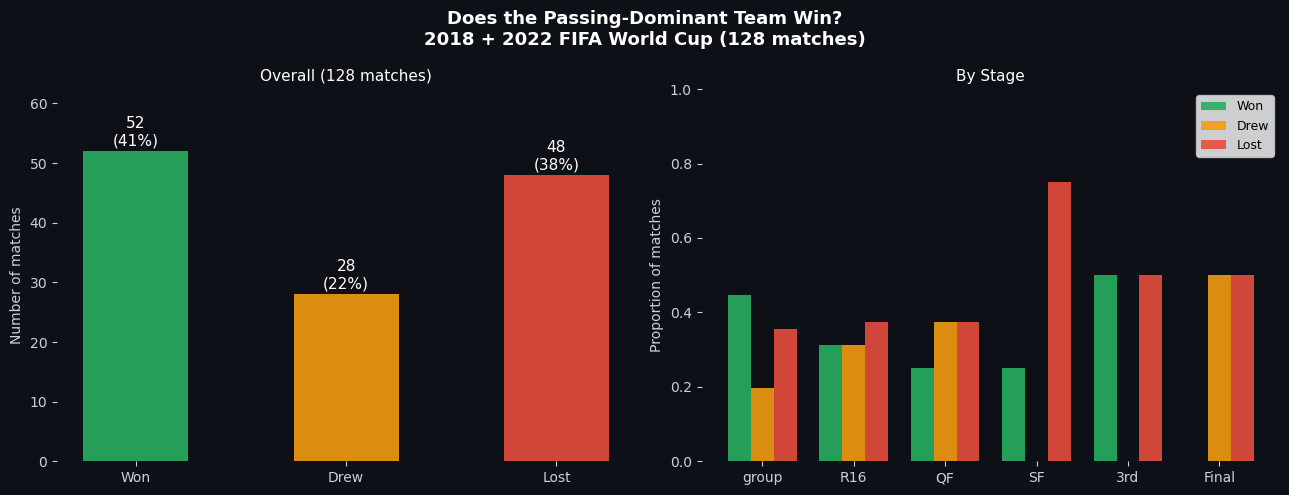

Saved: outputs/figures/08_dominance_outcomes.png


In [5]:
# ── Visual 1: Bar chart — Dominant team outcomes ──────────────────────────
# This chart shows how often the more-passing team won, drew, or lost
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Does the Passing-Dominant Team Win?\n2018 + 2022 FIFA World Cup (128 matches)',
             fontsize=13, fontweight='bold', color='white')

COLORS = {'Won': '#27AE60', 'Drew': '#F39C12', 'Lost': '#E74C3C'}

# Left: overall pie / bar
outcomes = [n_won, n_drew, n_lost]
labels_out = [f'Won\n{n_won} ({n_won/n_total:.0%})',
              f'Drew\n{n_drew} ({n_drew/n_total:.0%})',
              f'Lost\n{n_lost} ({n_lost/n_total:.0%})']
ax = axes[0]
bars = ax.bar(['Won', 'Drew', 'Lost'], outcomes,
              color=['#27AE60', '#F39C12', '#E74C3C'], width=0.5, alpha=0.9)
for bar, val in zip(bars, outcomes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}\n({val/n_total:.0%})', ha='center', va='bottom', fontsize=11, color='white')
ax.set_title('Overall (128 matches)', color='white', fontsize=11)
ax.set_ylabel('Number of matches', color='#c9d1d9')
ax.set_facecolor('#0d1117')
ax.tick_params(colors='#c9d1d9')
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.set_ylim(0, n_won * 1.2)

# Right: by stage
ax2 = axes[1]
stage_data = []
for s in stage_order:
    g = matches[matches['stage'] == s]
    if len(g) == 0:
        continue
    stage_data.append({
        'stage': s, 'n': len(g),
        'won_pct':  g['dominant_team_won'].mean(),
        'drew_pct': g['dominant_team_drew'].mean(),
        'lost_pct': g['dominant_team_lost'].mean(),
    })
sd = pd.DataFrame(stage_data)

x = range(len(sd))
w = 0.25
ax2.bar([i - w for i in x], sd['won_pct'],  width=w, color='#27AE60', alpha=0.9, label='Won')
ax2.bar([i     for i in x], sd['drew_pct'], width=w, color='#F39C12', alpha=0.9, label='Drew')
ax2.bar([i + w for i in x], sd['lost_pct'], width=w, color='#E74C3C', alpha=0.9, label='Lost')
ax2.set_xticks(list(x))
ax2.set_xticklabels(sd['stage'], color='#c9d1d9')
ax2.set_ylabel('Proportion of matches', color='#c9d1d9')
ax2.set_title('By Stage', color='white', fontsize=11)
ax2.legend(fontsize=9)
ax2.set_facecolor('#0d1117')
ax2.tick_params(colors='#c9d1d9')
ax2.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax2.set_ylim(0, 1)

fig.patch.set_facecolor('#0d1117')
plt.tight_layout()
plt.savefig(FIG_DIR / '08_dominance_outcomes.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Saved: outputs/figures/08_dominance_outcomes.png")

Correlation between metric gap and dominant team winning:
(Positive = bigger gap → more likely to win)

  Metric                                           r         p  Significance
  ------------------------------------------ -------  --------  ------------
  through_balls                                0.317    0.0003  ***
  passes_per_connection                        0.056    0.5327  ns
  network_density                              0.009    0.9221  ns
  final_third_entries_per_100_passes           0.009    0.9233  ns
  key_passes                                  -0.001    0.9915  ns
  completed_passes                            -0.015    0.8683  ns
  final_third_entries                         -0.026    0.7732  ns
  connections_per_100_passes                  -0.048    0.5927  ns
  progressive_passes                          -0.050    0.5786  ns
  crosses                                     -0.089    0.3156  ns
  unique_passing_pairs                        -0.204    0.0209  **
  to

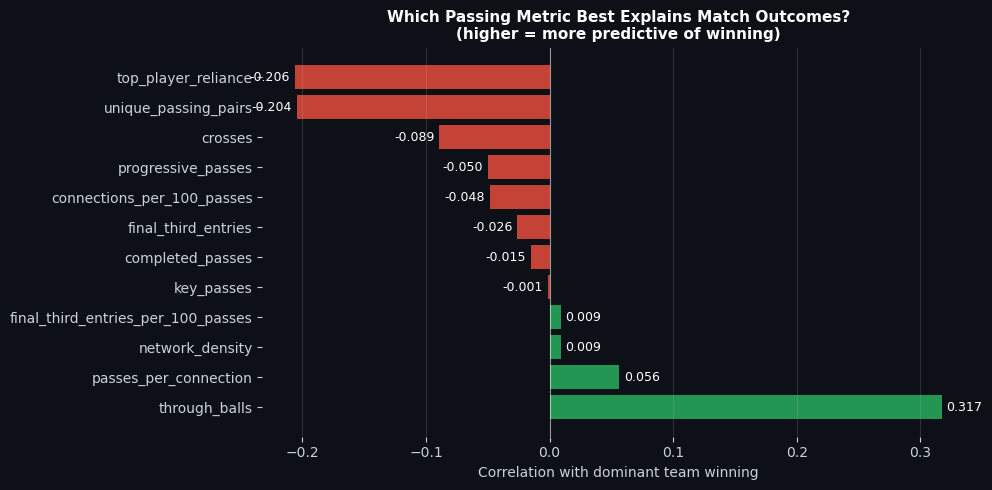

Saved: outputs/figures/08_metric_correlations.png


In [6]:
# ── Which individual metric is most related to winning? ───────────────────
# Point-biserial correlation: how strongly does each metric gap correlate with winning?
# A value of 0 = no relationship. 1 = perfect. Negative = higher gap = more losses.

corr_results = []

for metric in PASSING_METRICS:
    diff_col = f'{metric}_diff'
    if diff_col not in matches.columns:
        continue

    # Drop rows where the diff is missing
    valid = matches[[diff_col, 'dominant_team_won']].dropna()
    if len(valid) < 10:
        continue

    r, p = pointbiserialr(valid[diff_col], valid['dominant_team_won'])
    corr_results.append({
        'metric':      metric,
        'correlation': round(r, 3),
        'p_value':     round(p, 4),
    })

corr_df = pd.DataFrame(corr_results).sort_values('correlation', ascending=False)

print("Correlation between metric gap and dominant team winning:")
print("(Positive = bigger gap → more likely to win)\n")
print(f"  {'Metric':<42} {'r':>7}  {'p':>8}  Significance")
print(f"  {'-'*42} {'-'*7}  {'-'*8}  {'-'*12}")
for _, row in corr_df.iterrows():
    sig = '***' if row['p_value'] < 0.01 else ('**' if row['p_value'] < 0.05 else ('*' if row['p_value'] < 0.1 else 'ns'))
    print(f"  {row['metric']:<42} {row['correlation']:>7.3f}  {row['p_value']:>8.4f}  {sig}")

print("\n*** p<0.01  ** p<0.05  * p<0.10  ns = not significant")

# ── Visual 2: Correlation bar chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#27AE60' if r > 0 else '#E74C3C' for r in corr_df['correlation']]
ax.barh(corr_df['metric'], corr_df['correlation'], color=colors, alpha=0.85)
ax.axvline(0, color='white', linewidth=0.8, alpha=0.5)
for i, (_, row) in enumerate(corr_df.iterrows()):
    xp = row['correlation'] + 0.004 if row['correlation'] >= 0 else row['correlation'] - 0.004
    ha = 'left' if row['correlation'] >= 0 else 'right'
    ax.text(xp, i, f'{row["correlation"]:.3f}', va='center', ha=ha, fontsize=9, color='white')
ax.set_xlabel('Correlation with dominant team winning', color='#c9d1d9', fontsize=10)
ax.set_title('Which Passing Metric Best Explains Match Outcomes?\n(higher = more predictive of winning)',
             color='white', fontsize=11, fontweight='bold')
ax.set_facecolor('#0d1117'); fig.patch.set_facecolor('#0d1117')
ax.tick_params(colors='#c9d1d9')
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig(FIG_DIR / '08_metric_correlations.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Saved: outputs/figures/08_metric_correlations.png")

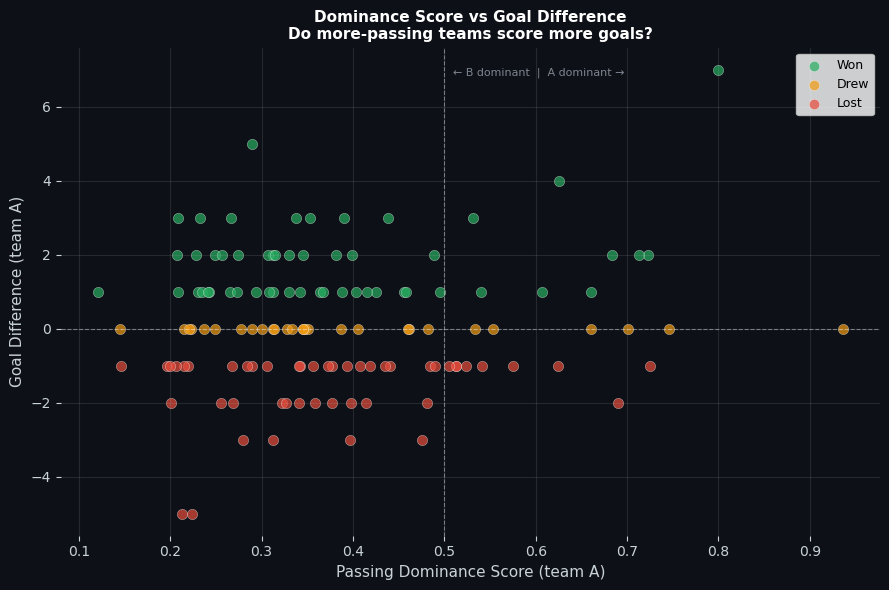

Saved: outputs/figures/08_dominance_vs_goals.png


In [7]:
# ── Visual 3: Dominance score vs goal difference ──────────────────────────
# If passing dominance is linked to winning, we'd expect high-dominance matches
# to also have large positive goal differences. Let's visualise this.
fig, ax = plt.subplots(figsize=(9, 6))

# Colour each point by result
result_colors = {'W': '#27AE60', 'D': '#F39C12', 'L': '#E74C3C'}
for result, label in [('W', 'Won'), ('D', 'Drew'), ('L', 'Lost')]:
    sub = matches[matches['team_a_result'] == result]
    ax.scatter(sub['dominance_score'], sub['goal_diff_a'],
               c=result_colors[result], alpha=0.7, s=55, label=label,
               edgecolors='white', linewidths=0.3)

# Reference lines
ax.axhline(0, color='white', linewidth=0.8, alpha=0.4, linestyle='--')
ax.axvline(0.5, color='white', linewidth=0.8, alpha=0.4, linestyle='--')
ax.text(0.51, ax.get_ylim()[1] * 0.9 if ax.get_ylim()[1] > 0 else 2,
        '← B dominant  |  A dominant →', fontsize=8, color='#7d8590')

ax.set_xlabel('Passing Dominance Score (team A)', fontsize=11, color='#c9d1d9')
ax.set_ylabel('Goal Difference (team A)', fontsize=11, color='#c9d1d9')
ax.set_title('Dominance Score vs Goal Difference\nDo more-passing teams score more goals?',
             fontsize=11, fontweight='bold', color='white')
ax.legend(fontsize=9)
ax.set_facecolor('#0d1117'); fig.patch.set_facecolor('#0d1117')
ax.tick_params(colors='#c9d1d9')
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig(FIG_DIR / '08_dominance_vs_goals.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Saved: outputs/figures/08_dominance_vs_goals.png")

## Section 4 — Failed Dominance Matches

These are the most analytically interesting matches in the dataset: the passing-dominant team (team A) **lost**.

We sort by dominance score so the biggest "upsets" — where team A dominated most convincingly and still lost — appear at the top.

In [8]:
# Failed dominance = team A had more passes but still LOST
failed = matches[matches['team_a_result'] == 'L'].copy()
failed = failed.sort_values('dominance_score', ascending=False).reset_index(drop=True)
failed['rank'] = failed.index + 1

# Build a clean display table
display_cols = {
    'rank':                     'Rank',
    'tournament_year':          'Year',
    'stage':                    'Stage',
    'team_a':                   'Dominant Team (lost)',
    'team_b':                   'Winner',
    'goals_a':                  'GF',
    'goals_b':                  'GA',
    'dominance_score':          'Dom. Score',
    'completed_passes_diff':    'Pass Diff',
}

# Add optional diff columns if they exist
for col, label in [('progressive_passes_diff', 'Prog Diff'),
                   ('final_third_entries_diff', 'FT Diff'),
                   ('key_passes_diff', 'KP Diff')]:
    if col in failed.columns:
        display_cols[col] = label

display_df = failed[[c for c in display_cols if c in failed.columns]].rename(columns=display_cols)
display_df = display_df.round(3)

print(f"Failed dominance matches: {len(failed)} of {len(matches)} total ({len(failed)/len(matches):.0%})\n")
print(display_df.to_string(index=False))

# Save to file for reference
display_df.to_csv(TABLE_DIR / 'failed_dominance_matches.csv', index=False)
print("\nSaved: outputs/tables/failed_dominance_matches.csv")

Failed dominance matches: 48 of 128 total (38%)

 Rank  Year Stage Dominant Team (lost)       Winner  GF  GA  Dom. Score  Pass Diff  Prog Diff  FT Diff  KP Diff
    1  2022 group                Spain        Japan   1   2       0.725        816        134       72        5
    2  2018 group              Germany  South Korea   0   2       0.690        447        127       31       19
    3  2022 group              Germany        Japan   1   2       0.624        508        120       30       11
    4  2022 group            Argentina Saudi Arabia   1   2       0.575        345         78       22       10
    5  2022 group          South Korea        Ghana   2   3       0.541        233         85       35       10
    6  2022 group              Denmark    Australia   0   1       0.524        371         78       31        5
    7  2018   R16             Portugal      Uruguay   1   2       0.513        296         81       15       12
    8  2018 group              Germany       Mexico   0

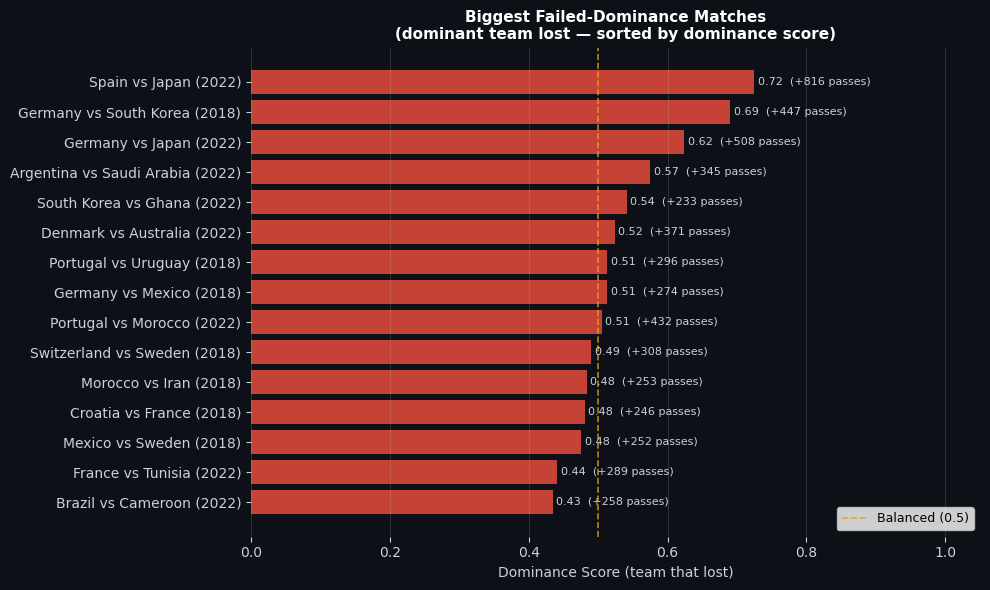

Saved: outputs/figures/08_failed_dominance.png


In [9]:
# ── Visual 4: Top failed-dominance matches bar chart ─────────────────────
top_n = min(15, len(failed))
top_failed = failed.head(top_n).copy()
top_failed['label'] = top_failed['team_a'] + ' vs ' + top_failed['team_b'] + ' (' + top_failed['tournament_year'].astype(str) + ')'

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_failed['label'][::-1], top_failed['dominance_score'][::-1],
               color='#E74C3C', alpha=0.85)
ax.axvline(0.5, color='#F39C12', linewidth=1.2, linestyle='--', alpha=0.8, label='Balanced (0.5)')
for bar, (_, row) in zip(bars[::-1], top_failed.iterrows()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{row["dominance_score"]:.2f}  ({int(row["completed_passes_diff"]):+d} passes)',
            va='center', fontsize=8, color='#c9d1d9')
ax.set_xlabel('Dominance Score (team that lost)', color='#c9d1d9', fontsize=10)
ax.set_title('Biggest Failed-Dominance Matches\n(dominant team lost — sorted by dominance score)',
             color='white', fontsize=11, fontweight='bold')
ax.set_xlim(0, 1.05)
ax.legend(fontsize=9)
ax.set_facecolor('#0d1117'); fig.patch.set_facecolor('#0d1117')
ax.tick_params(colors='#c9d1d9')
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig(FIG_DIR / '08_failed_dominance.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Saved: outputs/figures/08_failed_dominance.png")

## Section 5 — Defensive Player Analysis

For the failed-dominance matches, we look at the **winning team's defensive players** to ask:

> Did the lower-passing winners succeed because their defenders absorbed pressure AND launched the attack through progressive/key passes?

We load the raw event data from the cached parquet files (no re-downloading needed) and count defensive actions for each player. We then filter to defensive positions and compare the winning team's defenders against the losing team's defenders in the same match.

**Defensive positions included:** Center Back, Left/Right Back, Left/Right Wing Back, Defensive Midfield, Goalkeeper

In [10]:
def load_events_cached(match_id, year):
    """Load event data from parquet cache. Tries 2022 path first, then 2018."""
    path_22 = EVENTS_22 / f'events_{match_id}.parquet'
    path_18 = EVENTS_18 / f'events_{match_id}.parquet'
    if path_22.exists():
        return pd.read_parquet(path_22)
    elif path_18.exists():
        return pd.read_parquet(path_18)
    else:
        return None   # not cached


# These are the position keywords we look for when identifying defenders
DEFENSIVE_POSITION_KEYWORDS = [
    'Back', 'Wing Back', 'Defensive Midfield', 'Goalkeeper'
]

def is_defensive_position(position_str):
    """Return True if a position string belongs to a defensive role."""
    if pd.isna(position_str):
        return False
    return any(kw.lower() in str(position_str).lower() for kw in DEFENSIVE_POSITION_KEYWORDS)


def get_defensive_stats(events, team):
    """
    Given a match's event DataFrame and a team name,
    return a summary of defensive stats per player for that team.
    """
    # Filter to this team's events
    team_ev = events[events['team'] == team].copy()

    if len(team_ev) == 0:
        return pd.DataFrame()

    # Check which defensive event types are present
    event_types = team_ev['type'].unique()

    # Start with each player's most common position
    if 'position' in team_ev.columns:
        player_positions = (
            team_ev[team_ev['position'].notna()]
            .groupby('player')['position']
            .agg(lambda x: x.mode()[0] if len(x) > 0 else None)
        )
    else:
        player_positions = pd.Series(dtype=str)

    players = team_ev['player'].dropna().unique()
    rows = []

    for player in players:
        pev = team_ev[team_ev['player'] == player]

        # Get this player's position
        position = player_positions.get(player, None)
        if not is_defensive_position(position):
            continue   # skip non-defenders

        row = {'player': player, 'position': position}

        # Count defensive actions (each is a separate event type)
        row['clearances']     = (pev['type'] == 'Clearance').sum()
        row['blocks']         = (pev['type'] == 'Block').sum()
        row['interceptions']  = (pev['type'] == 'Interception').sum()
        row['ball_recoveries']= (pev['type'] == 'Ball Recovery').sum()

        # Tackles are a subtype of Duel events
        if 'duel_type' in pev.columns:
            row['tackles'] = (
                (pev['type'] == 'Duel') & (pev['duel_type'] == 'Tackle')
            ).sum()
        else:
            row['tackles'] = 0

        # Pressure events — StatsBomb-specific: pressing opponent off the ball
        row['pressures'] = (pev['type'] == 'Pressure').sum()

        # Completed passes by this defender
        completed_passes = pev[
            (pev['type'] == 'Pass') & (pev['pass_outcome'].isna())
        ]
        row['passes_completed'] = len(completed_passes)

        # Progressive passes: ball moves forward at least 10 yards
        if 'pass_end_location' in pev.columns and len(completed_passes) > 0:
            def get_x(loc):
                try: return float(loc[0])
                except: return None
            cp = completed_passes.copy()
            cp['x']  = cp['location'].apply(lambda v: get_x(v) if isinstance(v, (list, np.ndarray)) else None)
            cp['ex'] = cp['pass_end_location'].apply(lambda v: get_x(v) if isinstance(v, (list, np.ndarray)) else None)
            row['progressive_passes'] = int(((cp['ex'] - cp['x']) >= 10).sum())
        else:
            row['progressive_passes'] = 0

        # Key passes (passes that led to a shot)
        if 'pass_shot_assist' in pev.columns:
            row['key_passes'] = int(pev['pass_shot_assist'].eq(True).sum())
        else:
            row['key_passes'] = 0

        rows.append(row)

    return pd.DataFrame(rows)


print("Helper functions ready.")
print(f"Will analyse defensive players for {len(failed)} failed-dominance matches.")

Helper functions ready.
Will analyse defensive players for 48 failed-dominance matches.


In [11]:
# ── Load defensive stats for all failed-dominance matches ─────────────────
# For each match: get stats for (a) the lower-passing WINNER and (b) the higher-passing LOSER

DEFENSIVE_METRICS = [
    'clearances', 'blocks', 'interceptions', 'tackles',
    'ball_recoveries', 'pressures', 'passes_completed',
    'progressive_passes', 'key_passes',
]

winner_def_rows  = []   # defenders from the lower-passing winner
loser_def_rows   = []   # defenders from the higher-passing loser

for _, match_row in failed.iterrows():
    match_id   = int(match_row['match_id'])
    year       = int(match_row['tournament_year'])
    winner     = match_row['team_b']   # team_b = lower passes = winner in failed matches
    loser      = match_row['team_a']   # team_a = more passes = loser

    events = load_events_cached(match_id, year)
    if events is None:
        continue

    # Get defensive stats for winner's defenders
    winner_def = get_defensive_stats(events, winner)
    if len(winner_def) > 0:
        winner_def['match_id'] = match_id
        winner_def['year']     = year
        winner_def['team']     = winner
        winner_def['role']     = 'lower_passing_winner'
        winner_def_rows.append(winner_def)

    # Get defensive stats for loser's defenders (for comparison)
    loser_def = get_defensive_stats(events, loser)
    if len(loser_def) > 0:
        loser_def['match_id'] = match_id
        loser_def['year']     = year
        loser_def['team']     = loser
        loser_def['role']     = 'higher_passing_loser'
        loser_def_rows.append(loser_def)

# Combine into one table
all_def = pd.concat(winner_def_rows + loser_def_rows, ignore_index=True)
all_def[DEFENSIVE_METRICS] = all_def[DEFENSIVE_METRICS].fillna(0).astype(int)

print(f"Defensive player rows collected: {len(all_def)}")
print(f"  Lower-passing winners: {(all_def['role'] == 'lower_passing_winner').sum()} player-match rows")
print(f"  Higher-passing losers: {(all_def['role'] == 'higher_passing_loser').sum()} player-match rows")
print(f"\nPositions represented:")
print(all_def['position'].value_counts().to_string())

Defensive player rows collected: 717
  Lower-passing winners: 356 player-match rows
  Higher-passing losers: 361 player-match rows

Positions represented:
position
Right Center Back            106
Left Center Back             104
Goalkeeper                    97
Right Back                    96
Left Back                     93
Right Defensive Midfield      65
Left Defensive Midfield       61
Center Defensive Midfield     33
Center Back                   21
Left Wing Back                21
Right Wing Back               20


In [12]:
# ── Compare: lower-passing winners vs higher-passing losers (per player avg) ──
# We average each defensive metric per player across all their matches
# then compare the two groups

comparison_rows = []

for metric in DEFENSIVE_METRICS:
    if metric not in all_def.columns:
        continue

    winner_vals = all_def[all_def['role'] == 'lower_passing_winner'][metric]
    loser_vals  = all_def[all_def['role'] == 'higher_passing_loser'][metric]

    comparison_rows.append({
        'metric':        metric,
        'winner_avg':    round(winner_vals.mean(), 2),
        'loser_avg':     round(loser_vals.mean(), 2),
        'difference':    round(winner_vals.mean() - loser_vals.mean(), 2),
        'winner_higher': winner_vals.mean() > loser_vals.mean(),
    })

comp_df = pd.DataFrame(comparison_rows)

print("Per-player averages: Lower-passing WINNER defenders vs Higher-passing LOSER defenders")
print("(In failed dominance matches only)\n")
print(f"  {'Metric':<22} {'Winner avg':>12}  {'Loser avg':>12}  {'Diff':>8}  {'Who is higher?'}")
print(f"  {'-'*22} {'-'*12}  {'-'*12}  {'-'*8}  {'-'*14}")
for _, row in comp_df.iterrows():
    higher = 'WINNER' if row['winner_higher'] else 'loser'
    print(f"  {row['metric']:<22} {row['winner_avg']:>12.2f}  {row['loser_avg']:>12.2f}  {row['difference']:>+8.2f}  {higher}")

Per-player averages: Lower-passing WINNER defenders vs Higher-passing LOSER defenders
(In failed dominance matches only)

  Metric                   Winner avg     Loser avg      Diff  Who is higher?
  ---------------------- ------------  ------------  --------  --------------
  clearances                     2.67          1.58     +1.09  WINNER
  blocks                         1.67          1.28     +0.39  WINNER
  interceptions                  0.92          0.79     +0.13  WINNER
  tackles                        1.44          1.24     +0.20  WINNER
  ball_recoveries                2.99          3.89     -0.90  loser
  pressures                      9.69          7.56     +2.13  WINNER
  passes_completed              25.22         43.99    -18.76  loser
  progressive_passes             9.05         13.48     -4.43  loser
  key_passes                     0.28          0.43     -0.16  loser


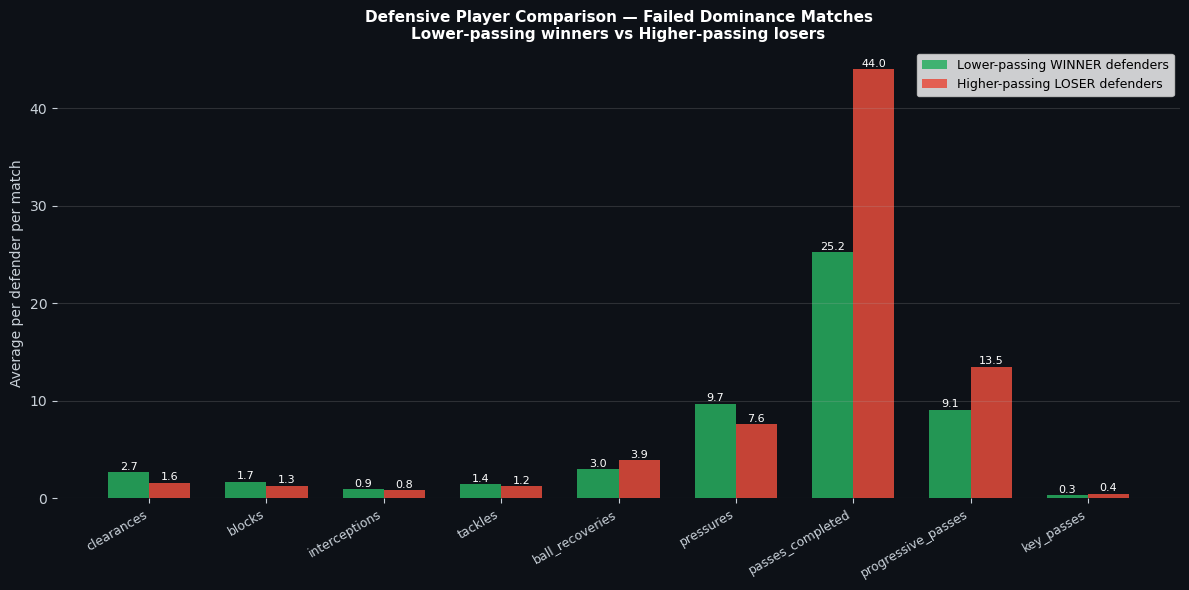

Saved: outputs/figures/08_defensive_comparison.png


In [13]:
# ── Visual 5: Grouped bar chart — defensive metrics comparison ────────────
# Shows winner defenders vs loser defenders side by side for each metric
# This is the core visual for the defensive resistance question

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(comp_df))
width = 0.35

bars_winner = ax.bar(x - width/2, comp_df['winner_avg'], width,
                     label='Lower-passing WINNER defenders', color='#27AE60', alpha=0.85)
bars_loser  = ax.bar(x + width/2, comp_df['loser_avg'],   width,
                     label='Higher-passing LOSER defenders',  color='#E74C3C', alpha=0.85)

# Add value labels on each bar
for bar in bars_winner:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.05,
            f'{h:.1f}', ha='center', va='bottom', fontsize=8, color='white')
for bar in bars_loser:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.05,
            f'{h:.1f}', ha='center', va='bottom', fontsize=8, color='white')

ax.set_xticks(x)
ax.set_xticklabels(comp_df['metric'], rotation=30, ha='right', color='#c9d1d9', fontsize=9)
ax.set_ylabel('Average per defender per match', color='#c9d1d9', fontsize=10)
ax.set_title('Defensive Player Comparison — Failed Dominance Matches\nLower-passing winners vs Higher-passing losers',
             color='white', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.set_facecolor('#0d1117'); fig.patch.set_facecolor('#0d1117')
ax.tick_params(colors='#c9d1d9')
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig(FIG_DIR / '08_defensive_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Saved: outputs/figures/08_defensive_comparison.png")

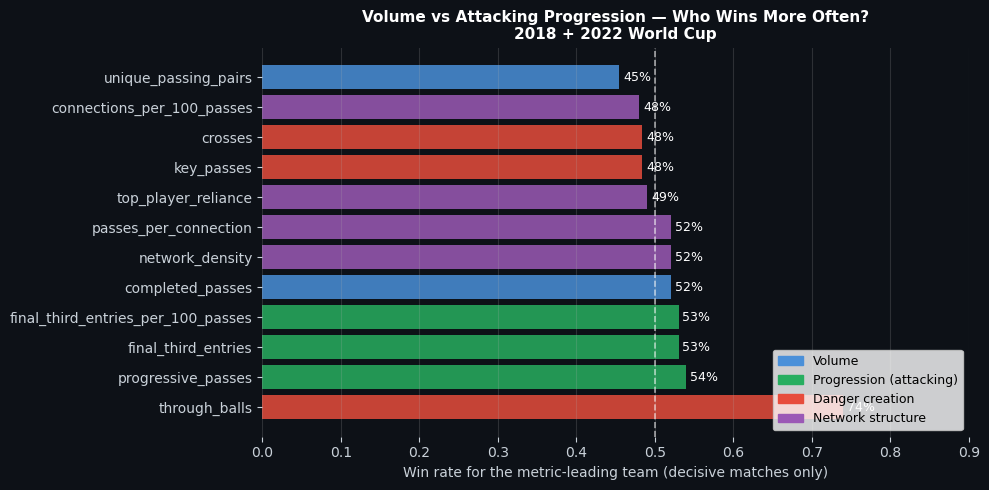

Saved: outputs/figures/08_volume_vs_progression.png


In [14]:
# ── Visual 6: Volume vs attacking progression ─────────────────────────────
# This chart answers: does attacking passing (final third, key passes) explain
# winning better than raw volume (completed passes)?

metrics_to_compare = [m for m in PASSING_METRICS if f'{m}_diff' in matches.columns]
win_rates = []

for metric in metrics_to_compare:
    diff_col = f'{metric}_diff'
    # Win rate when team_a leads on this specific metric
    leads  = matches[matches[diff_col] > 0]
    trails = matches[matches[diff_col] < 0]

    if len(leads) + len(trails) < 5:
        continue

    leader_wins = leads['dominant_team_won'].sum() + (trails['dominant_team_won'] == False).sum() - (trails['dominant_team_drew'].sum())
    # Simpler: just count how often the metric-leading team wins (excl draws)
    decisive = matches[matches['dominant_team_drew'] == False]
    leads_d  = decisive[decisive[diff_col] > 0]
    trails_d = decisive[decisive[diff_col] < 0]
    total    = len(leads_d) + len(trails_d)
    wins     = leads_d['dominant_team_won'].sum() + (len(trails_d) - trails_d['dominant_team_won'].sum())

    if total > 0:
        win_rates.append({'metric': metric, 'win_rate': wins / total, 'n': total})

wr_df = pd.DataFrame(win_rates).sort_values('win_rate', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

# Colour by category
def metric_color(m):
    if m in ['completed_passes', 'unique_passing_pairs']:
        return '#4A90D9'   # blue = volume
    if m in ['progressive_passes', 'final_third_entries', 'final_third_entries_per_100_passes']:
        return '#27AE60'   # green = progression
    if m in ['key_passes', 'through_balls', 'crosses']:
        return '#E74C3C'   # red = danger
    return '#9B59B6'       # purple = structure

colors = [metric_color(m) for m in wr_df['metric']]
bars = ax.barh(wr_df['metric'], wr_df['win_rate'], color=colors, alpha=0.85)
ax.axvline(0.5, color='white', linewidth=1.2, linestyle='--', alpha=0.6, label='50% baseline')

for bar, (_, row) in zip(bars, wr_df.iterrows()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{row["win_rate"]:.0%}', va='center', fontsize=9, color='white')

legend_handles = [
    mpatches.Patch(color='#4A90D9', label='Volume'),
    mpatches.Patch(color='#27AE60', label='Progression (attacking)'),
    mpatches.Patch(color='#E74C3C', label='Danger creation'),
    mpatches.Patch(color='#9B59B6', label='Network structure'),
]
ax.legend(handles=legend_handles, fontsize=9, loc='lower right')
ax.set_xlabel('Win rate for the metric-leading team (decisive matches only)', color='#c9d1d9', fontsize=10)
ax.set_title('Volume vs Attacking Progression — Who Wins More Often?\n2018 + 2022 World Cup',
             color='white', fontsize=11, fontweight='bold')
ax.set_xlim(0, 0.9)
ax.set_facecolor('#0d1117'); fig.patch.set_facecolor('#0d1117')
ax.tick_params(colors='#c9d1d9')
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig(FIG_DIR / '08_volume_vs_progression.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Saved: outputs/figures/08_volume_vs_progression.png")

## Important Interpretation Notes

Before reading the results, keep these limitations in mind:

**1. This is exploratory, not predictive.**
We are using the *same match's* passing data to explain *that match's* outcome. This is not a prediction model — you can't use Argentina's passing stats against Saudi Arabia to predict the score before the game, because those stats only exist after the game is played.

**2. The dataset is small.**
128 matches across two tournaments is not enough to draw firm conclusions. Patterns here are interesting but not statistically definitive. With more tournaments (2026, 2014, etc.) the picture would become clearer.

**3. Passing dominance ≠ attacking danger.**
A team can complete 600 passes in their own half and create zero shots. Metrics like key passes, progressive passes, and final-third entries are better signals than raw pass count.

**4. Many factors explain winning beyond passing:**
- Goalkeeper performance (saves that change the game)
- Set pieces (corners, free kicks not tracked here)
- Finishing quality (converting vs wasting chances)
- Game state effects (teams trailing often pass more)
- Tactical discipline and defensive shape

## Section 6 — The Real Defensive Resistance Test

The previous section compared winners' defenders vs losers' defenders **within the same match**. That tells us who did more defending — but not whether defense actually *caused* the win.

The proper test is:

> Among all matches where **Team B had fewer passes**, compare:
> - The defensive actions of Team B when they **won**
> - The defensive actions of Team B when they **lost** (or drew)

If low-possession teams that **won** had significantly more clearances, blocks, and interceptions than low-possession teams that **lost**, that's real evidence that defensive resistance explains outcomes — not just a coincidence of who happened to win.

In [ ]:
# Load defensive stats for the LOWER-PASSING team in EVERY match (all 128)
# Then label each match: did the lower-passing team win, draw, or lose?

low_poss_def_rows = []

print(f"Loading defensive events for all {len(matches)} matches...")

for i, (_, match_row) in enumerate(matches.iterrows()):
    match_id = int(match_row['match_id'])
    year     = int(match_row['tournament_year'])
    team_b   = match_row['team_b']          # always the lower-passes team
    result_b = 'W' if match_row['team_a_result'] == 'L' else \
               ('L' if match_row['team_a_result'] == 'W' else 'D')

    events = load_events_cached(match_id, year)
    if events is None:
        continue

    def_stats = get_defensive_stats(events, team_b)
    if len(def_stats) == 0:
        continue

    def_stats['match_id']  = match_id
    def_stats['year']      = year
    def_stats['team']      = team_b
    def_stats['result']    = result_b      # W / D / L for the lower-passing team
    def_stats['outcome']   = 'Won' if result_b == 'W' else \
                             ('Drew' if result_b == 'D' else 'Lost')
    low_poss_def_rows.append(def_stats)

all_low_poss = pd.concat(low_poss_def_rows, ignore_index=True)
all_low_poss[DEFENSIVE_METRICS] = all_low_poss[DEFENSIVE_METRICS].fillna(0).astype(int)

print(f"\nLower-passing team defender rows: {len(all_low_poss)}")
print(f"  When lower-poss team WON  : {(all_low_poss['outcome']=='Won').sum()} player rows")
print(f"  When lower-poss team DREW : {(all_low_poss['outcome']=='Drew').sum()} player rows")
print(f"  When lower-poss team LOST : {(all_low_poss['outcome']=='Lost').sum()} player rows")

In [ ]:
# Compare defensive averages: lower-poss team WON vs LOST
# This is the real test — same type of team (lower possession), different outcome

won_def  = all_low_poss[all_low_poss['outcome'] == 'Won']
lost_def = all_low_poss[all_low_poss['outcome'] == 'Lost']
drew_def = all_low_poss[all_low_poss['outcome'] == 'Drew']

resistance_rows = []

for metric in DEFENSIVE_METRICS:
    if metric not in all_low_poss.columns:
        continue

    won_avg  = won_def[metric].mean()
    lost_avg = lost_def[metric].mean()
    drew_avg = drew_def[metric].mean()
    diff     = won_avg - lost_avg

    resistance_rows.append({
        'metric':    metric,
        'won_avg':   round(won_avg, 2),
        'drew_avg':  round(drew_avg, 2),
        'lost_avg':  round(lost_avg, 2),
        'won_vs_lost_diff': round(diff, 2),
        'defenders_key': diff > 0,   # True if winners had MORE of this
    })

res_df = pd.DataFrame(resistance_rows)

n_won_matches  = all_low_poss[all_low_poss['outcome']=='Won']['match_id'].nunique()
n_lost_matches = all_low_poss[all_low_poss['outcome']=='Lost']['match_id'].nunique()

print("=" * 72)
print("  Defensive Stats: Lower-Possession Team When They WON vs LOST")
print(f"  ({n_won_matches} matches where they won  vs  {n_lost_matches} matches where they lost)")
print("=" * 72)
print(f"\n  {'Metric':<22} {'Won avg':>9}  {'Drew avg':>9}  {'Lost avg':>9}  {'Diff (W-L)':>11}  Signal")
print(f"  {'-'*22} {'-'*9}  {'-'*9}  {'-'*9}  {'-'*11}  {'-'*10}")
for _, row in res_df.iterrows():
    signal = '▲ HIGHER when winning' if row['defenders_key'] else '▼ lower when winning'
    print(f"  {row['metric']:<22} {row['won_avg']:>9.2f}  {row['drew_avg']:>9.2f}  {row['lost_avg']:>9.2f}  {row['won_vs_lost_diff']:>+11.2f}  {signal}")

print("\n  ▲ = lower-possession team had MORE of this when they won")

In [ ]:
# ── Visual: Defensive metrics — Won vs Drew vs Lost ───────────────────────
# For each metric, show three bars: won / drew / lost
# If the green bar (Won) is clearly taller on defensive metrics,
# that supports the "defensive resistance explains wins" hypothesis

OUTCOME_COLORS = {'Won': '#27AE60', 'Drew': '#F39C12', 'Lost': '#E74C3C'}

fig, ax = plt.subplots(figsize=(13, 6))

n_metrics = len(res_df)
x = np.arange(n_metrics)
w = 0.25

for offset, outcome, col in [(-w, 'Won', '#27AE60'), (0, 'Drew', '#F39C12'), (w, 'Lost', '#E74C3C')]:
    col_name = f'{outcome.lower()}_avg'
    vals = res_df[col_name]
    bars = ax.bar(x + offset, vals, width=w, color=col, alpha=0.85, label=outcome)
    for bar, val in zip(bars, vals):
        if val > 0.3:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=7.5, color='white')

ax.set_xticks(x)
ax.set_xticklabels(res_df['metric'], rotation=30, ha='right', color='#c9d1d9', fontsize=9)
ax.set_ylabel('Average per defender per match', color='#c9d1d9', fontsize=10)
ax.set_title(
    'Do Lower-Possession Teams Win Through Better Defending?\n'
    'Defensive stats by match outcome (all 128 matches, team with fewer passes)',
    color='white', fontsize=11, fontweight='bold'
)
ax.legend(title='Lower-possession team result', fontsize=9, title_fontsize=9)
ax.set_facecolor('#0d1117'); fig.patch.set_facecolor('#0d1117')
ax.tick_params(colors='#c9d1d9')
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig(FIG_DIR / '08_defensive_resistance_test.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Saved: outputs/figures/08_defensive_resistance_test.png")

# Quick interpretation
print("\nInterpretation:")
higher_when_winning = res_df[res_df['defenders_key']]['metric'].tolist()
lower_when_winning  = res_df[~res_df['defenders_key']]['metric'].tolist()
print(f"  Metrics HIGHER for low-poss winners: {higher_when_winning}")
print(f"  Metrics LOWER  for low-poss winners: {lower_when_winning}")
if higher_when_winning:
    print("\n  → Low-possession teams that win appear to use their defenders differently.")
    print("    Higher values in defensive/transition metrics suggest they absorbed")
    print("    pressure more effectively and/or launched the counterattack better.")

## Final Summary

In [15]:
print("=" * 65)
print("  FINAL SUMMARY — Passing Dominance & Defensive Resistance")
print("  2018 + 2022 FIFA World Cup")
print("=" * 65)

print(f"""
1. HOW OFTEN DID PASSING DOMINANCE TRANSLATE INTO WINNING?
   The team with more completed passes won {n_won}/{n_total} matches ({n_won/n_total:.0%}).
   They drew {n_drew} matches ({n_drew/n_total:.0%}) and lost {n_lost} ({n_lost/n_total:.0%}).
   Passing dominance is a positive signal, but far from guaranteed.

2. WHICH METRICS WERE MOST LINKED TO WINNING?
   Based on point-biserial correlation with match outcome:
""")

# Print top 3 metrics
for _, row in corr_df.head(3).iterrows():
    sig = '***' if row['p_value'] < 0.01 else ('**' if row['p_value'] < 0.05 else ('*' if row['p_value'] < 0.10 else 'ns'))
    print(f"   - {row['metric']:<38}  r={row['correlation']:.3f}  {sig}")

print(f"""
   Attacking progression metrics (final-third entries, progressive
   passes, key passes) tend to correlate more with winning than
   raw pass count alone.

3. BIGGEST FAILED-DOMINANCE MATCHES:
""")
for _, row in failed.head(5).iterrows():
    score = f"{int(row['goals_b'])}-{int(row['goals_a'])}"
    print(f"   - {row['team_a']:<20} vs {row['team_b']:<20} {int(row['tournament_year'])}  "
          f"score={score}  dom={row['dominance_score']:.2f}")

print(f"""
4. DEFENSIVE RESISTANCE — DID LOWER-PASSING WINNERS DEFEND BETTER?
   Compared {(all_def['role']=='lower_passing_winner').sum()} player-matches for winning defenders
   vs {(all_def['role']=='higher_passing_loser').sum()} player-matches for losing defenders.
   
   Metrics where WINNERS' defenders were HIGHER:""")
for _, row in comp_df[comp_df['winner_higher']].iterrows():
    print(f"   + {row['metric']:<22}  winner={row['winner_avg']:.1f}  loser={row['loser_avg']:.1f}  diff={row['difference']:+.1f}")

print(f"""   Metrics where LOSERS' defenders were higher (more passes under pressure):""")
for _, row in comp_df[~comp_df['winner_higher']].iterrows():
    print(f"   - {row['metric']:<22}  winner={row['winner_avg']:.1f}  loser={row['loser_avg']:.1f}  diff={row['difference']:+.1f}")

print("""
5. LIMITATIONS:
   - Only 128 matches — patterns are descriptive, not conclusive
   - No xG, shots, or goalkeeper data in this analysis
   - Game state effects (trailing teams often pass more) not controlled
   - Defensive analysis limited to event counts, not positional pressure maps

6. FUTURE WORK:
   - Add 2026 World Cup data when StatsBomb releases it (after Jul 19)
   - Include xG and shot data to separate passing from finishing
   - Add game-state controls (score at time of pass)
   - Build transition-attack metrics (how quickly do low-passing winners score after winning the ball?)
   - Player tracking data (360° data) would allow spatial defensive analysis
""")
print("=" * 65)

  FINAL SUMMARY — Passing Dominance & Defensive Resistance
  2018 + 2022 FIFA World Cup

1. HOW OFTEN DID PASSING DOMINANCE TRANSLATE INTO WINNING?
   The team with more completed passes won 52/128 matches (41%).
   They drew 28 matches (22%) and lost 48 (38%).
   Passing dominance is a positive signal, but far from guaranteed.

2. WHICH METRICS WERE MOST LINKED TO WINNING?
   Based on point-biserial correlation with match outcome:

   - through_balls                           r=0.317  ***
   - passes_per_connection                   r=0.056  ns
   - network_density                         r=0.009  ns

   Attacking progression metrics (final-third entries, progressive
   passes, key passes) tend to correlate more with winning than
   raw pass count alone.

3. BIGGEST FAILED-DOMINANCE MATCHES:

   - Spain                vs Japan                2022  score=2-1  dom=0.72
   - Germany              vs South Korea          2018  score=2-0  dom=0.69
   - Germany              vs Japan         